# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [13]:
# Bibliotecas que serão utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

In [2]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')

# Exibir Data Frame
base.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


## A) Exploração e limpeza da base de dados

In [3]:
# Verificação do tipo de dados
base.dtypes

Year_Birth             int64
Education             object
Marital_Status        object
Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Complain               int64
WebPurchases           int64
dtype: object

In [4]:
# Verificação de valores nulos ou ausentes
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

In [5]:
# Verificação parcial de outliers
base.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


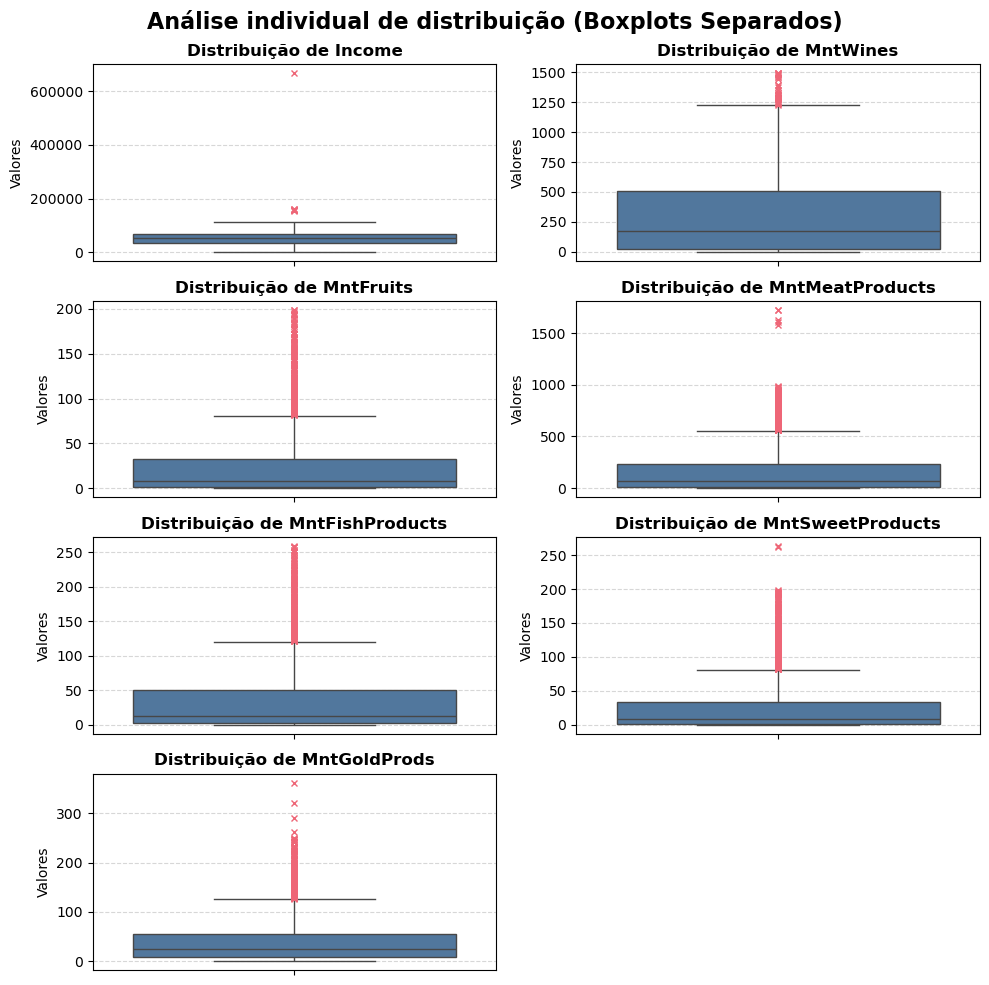

In [ ]:
# Lista com as variáveis para verificar a presesnça de outliers
colunas_analise = [
    'Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

# Configuração da grade de gráficos
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 10))

# Transformação da matriz de eixos em uma lista linear para facilitar o loop de preenchimento
axes = axes.flatten()

# Criação do Boxplot para cada variável na sua respectiva posição
for i, coluna in enumerate(colunas_analise):
    sns.boxplot(
        data=base, 
        y=coluna, 
        ax=axes[i], 
        color="#4477AA",
        flierprops={'marker': 'x', 'markersize': 5, 'markeredgecolor': '#EE6677'}
    )
    axes[i].set_title(f'Distribuição de {coluna}', fontsize=12, weight='bold')
    axes[i].set_ylabel('Valores')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Remoção do último gráfico que ficaria vazio
fig.delaxes(axes[-1])

# Ajuste do espaçamento para que os títulos e eixos não fiquem sobrepostos
plt.suptitle('Análise individual de distribuição (Boxplots Separados)', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()

# Exibição dos gráficos
plt.show()

In [7]:
# Verificação de valores discrepantes na variável "Income"
base['Income'].sort_values(ascending=False).head(10)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

In [8]:
# Verificação de anos discrepantes na variável "Year_Birth"
base.nsmallest(10, 'Year_Birth')[['Year_Birth', 'Income']]

,Year_Birth,Income
239,1893,60182.0
339,1899,83532.0
192,1900,36640.0
1950,1940,51141.0
424,1941,93027.0
39,1943,48948.0
358,1943,65073.0
415,1943,75865.0
894,1943,48948.0
1150,1943,57513.0


**Análise:** \
A análise visual dos boxplots e os resumos estatísticos revelam a presença clara de outliers que precisam ser tratados para evitar distorções nos modelos de machine learning. Na variável `Income`, foi identificado uma anomalia extrema onde um cliente possui renda de 666.666,00, um valor totalmente fora do padrão da base cuja mediana é de 51.381,50. Da mesma forma, na variável `Year_Birth`, foi encontrado registros com anos de nascimento a partir de 1893, o que indicaria clientes com mais de 120 anos de idade, configurando um erro de preenchimento ou ruído nos dados. Nas variáveis de consumo de produtos (`MntWines`, `MntFruits`, etc.), a presença de caudas longas de outliers reflete um comportamento real de consumo de clientes de altíssimo poder aquisitivo (heavy users), e não erros de sistema.

Para mitigar esses problemas sem perder o volume de dados, será utilizado uma estratégia de tratamento focada em substituição pela mediana. Primeiramente, os valores claramente discrepantes — como a renda isolada de 666.666,00 e os anos de nascimento anteriores a 1940 — serão convertidos em valores faltantes (NaN). Em seguida, para manter a consistência estatística da base e preencher essas lacunas com segurança, será realizado a imputação desses dados nulos utilizando a própria mediana de cada coluna correspondente, neutralizando o impacto das anomalias de forma limpa e eficiente.

In [9]:
# Susbsituição de outlier na variável "Income" por "NaN"
base['Income'] = base['Income'].replace(666666, np.nan)

# Substituição dos valore faltantes na variável "Income" pela mediana
base['Income'] = base['Income'].fillna(base['Income'].median())

In [10]:
# Susbsituição de outliers na variável "Year_Birth" por "NaN"
base.loc[base['Year_Birth'] < 1940, 'Year_Birth'] = np.nan

# Substituição dos valore faltantes na variável "Year_Birth" pela mediana
mediana = base['Year_Birth'].median()
base['Year_Birth'] = base['Year_Birth'].fillna(base['Year_Birth'].median())

In [11]:
# Conferência de valores discrepantes na variável "Income"
base['Income'].sort_values(ascending=False).head(10)

617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
252     102692.0
Name: Income, dtype: float64

In [12]:
# Conferência de anos discrepantes na variável "Year_Birth"
base.nsmallest(10, 'Year_Birth')[['Year_Birth', 'Income']]

,Year_Birth,Income
1950,1940.0,51141.0
424,1941.0,93027.0
39,1943.0,48948.0
358,1943.0,65073.0
415,1943.0,75865.0
894,1943.0,48948.0
1150,1943.0,57513.0
1923,1943.0,77598.0
2084,1943.0,51373.0
494,1944.0,55614.0


In [36]:
# Tradução das variáveis e dados para pt_BR
# Dicionário para renomear os nomes das variáveis
dicionario_var = {
    'Year_Birth': 'Ano_Nascimento',
    'Education': 'Escolaridade',
    'Marital_Status': 'Estado_Civil',
    'Income': 'Renda',
    'Kidhome': 'Filhos_em_Casa',
    'Recency': 'Recencia',
    'MntWines': 'Gasto_Vinhos',
    'MntFruits': 'Gasto_Frutas',
    'MntMeatProducts': 'Gasto_Carnes',
    'MntFishProducts': 'Gasto_Peixes',
    'MntSweetProducts': 'Gasto_Doces',
    'MntGoldProds': 'Gasto_Ouro',
    'NumStorePurchases': 'Num_Compras_Loja',
    'NumWebVisitsMonth': 'Num_Visitas_Web_Mes',
    'Complain': 'Reclamacao',
    'WebPurchases': 'Num_Compras_Web'
}

# Aplicar a renomeação das colunas
base = base.rename(columns=dicionario_var)

# Dicionário para traduzir as categorias de Escolaridade
traducao_escolaridade = {
    'Graduation': 'Graduacao', 
    'PhD': 'Doutorado', 
    'Master': 'Mestrado', 
    '2n Cycle': '2o Ciclo', 
    'Basic': 'Basico'
}

# Aplicar a tradução na coluna Escolaridade
base['Escolaridade'] = base['Escolaridade'].map(traducao_escolaridade).fillna(base['Escolaridade'])

# Dicionário para traduzir as categorias de Estado Civil
traducao_estado_civil = {
    'Married': 'Casado(a)', 
    'Together': 'Uniao Estavel', 
    'Single': 'Solteiro(a)', 
    'Divorced': 'Divorciado(a)', 
    'Widow': 'Viuvo(a)', 
    'Alone': 'Sozinho(a)', 
    'Absurd': 'Absurdo', 
    'YOLO': 'YOLO'
}

# Aplicar a tradução na coluna Estado Civil
base['Estado_Civil'] = base['Estado_Civil'].map(traducao_estado_civil).fillna(base['Estado_Civil'])

# Conferência do DataFrame traduzido 
base.head()

,Ano_Nascimento,Escolaridade,Estado_Civil,Renda,Filhos_em_Casa,Recencia,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,Gasto_Doces,Gasto_Ouro,Num_Compras_Loja,Num_Visitas_Web_Mes,Reclamacao,Num_Compras_Web
0,1957.0,Graduacao,Solteiro(a),58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954.0,Graduacao,Solteiro(a),46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965.0,Graduacao,Uniao Estavel,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984.0,Graduacao,Uniao Estavel,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981.0,Doutorado,Casado(a),58293.0,1,94,173,43,118,46,27,15,6,5,0,1


**Conclusão das análises e do que foi realizado:** \
A etapa de exploração e tratamento foi essencial para transformar dados brutos em uma base consistente e confiável para modelagem. O diagnóstico inicial revelou anomalias críticas de preenchimento na renda (`Renda` máxima de 666.666) e nas idades (`Ano_Nascimento` a partir de 1893), além de valores originalmente faltantes na coluna de renda. Para corrigir esses problemas sem reduzir o volume total de 2.240 registros, os dados discrepantes foram isolados e substituídos com sucesso pelas respectivas medianas das variáveis. As demais distribuições de consumo apresentaram comportamento coerente com o perfil de clientes de alto valor da marca. Como resultado, foi mitigado os ruídos estatísticos e garantido a integridade metodológica necessária para as próximas fases do projeto.

## B) Análise de dados

Ideias de análise 

Criar mapa de árvore contendo (Perfil dos clientes com mais compra online e compra fisica): Ano_Nascimento + Escolaridade + Estado_Civil + Filhos_em_Casa + Renda ++ Num_Compras_Loja + Num_Compras_Web.

- Se o cliente reclamou no ultimo dois anos e quantidade de compras feita diretamente do site da empresa e física: Reclamacao ++ Num_Compras_Web + Num_Compras_Loja;
- Número de compras feita diretamente da loja e número de compras feita diretamente do site da empresa e física: Num_Compras_Loja ++ Num_Compras_Web;
- Número de compras feita com desconto diretamente do site e fisico: NumDealsPurchases (Localizar) ++ Num_Compras_Web + Num_Compras_Loja;
- Valores gastos em cada produto diretamente no site e fisico: Gasto_Vinhos + Gasto_Frutas + Gasto_Carnes + Gasto_Peixes + Gasto_Doces + Gasto_Ouro ++ Num_Compras_Web + Num_Compras_Loja.

### Perfil dos clientes com mais compras realizadas atráves do site e compras físicas

**Objetivo:** identificar características sociodemográficas e financeiras associadas aos clientes que apresentam maior volume de compras nos canais online e físico.

In [37]:
# Agrupamento das informações dos clientes por média de compras realizadas através do site e compras físicas
compras_info_clientes = base.groupby(['Escolaridade', 'Estado_Civil', 'Filhos_em_Casa'])[['Renda', 'Num_Compras_Loja', 'Num_Compras_Web']].mean().reset_index()

# Criação da variável de total de compras realizadas (tanto pelo site quanto fisicas) para dimnesionar o gráfico
compras_info_clientes['Total_Compras'] = (compras_info_clientes['Num_Compras_Loja'] + 
                                           compras_info_clientes['Num_Compras_Web'])

# Criação do gráfico de treemap interativo
fig = px.treemap(compras_info_clientes,
                 path=['Escolaridade', 'Estado_Civil', 'Filhos_em_Casa'],
                 values='Total_Compras',
                 title='Compras totais (Online + Física) por características dos clientes',
                 color='Escolaridade',
                 hover_data={
                'Total_Compras': ':.2f',
                'Num_Compras_Loja': ':.2f', 
                'Num_Compras_Web': ':.2f',
                'Renda': ':.2f'
    }
)

# Ajuste estético para melhorar a visualização das caixas de texto
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

# Exibição do gráfico
fig.show()

**Insight:** \
O maior volume de vendas está concentrado em clientes com alto nível de escolaridade (Graduação, Mestrado e Doutorado), liderados destacadamente por pessoas casadas e sem filhos em casa (0). 

Em todos os principais perfis mapeados, o canal de lojas físicas supera massivamente o digital, indicando que, embora o público seja qualificado e de maior renda, a experiência de compra presencial ainda é o principal motor de conversão do negócio.

### Clientes que reclamaram nos ultimos dois anos, visitas ao site, quantidade de compras realizadas do site e compras físicas

**Objetivo:** verificar se clientes que registraram reclamações apresentam comportamento de compra diferente.

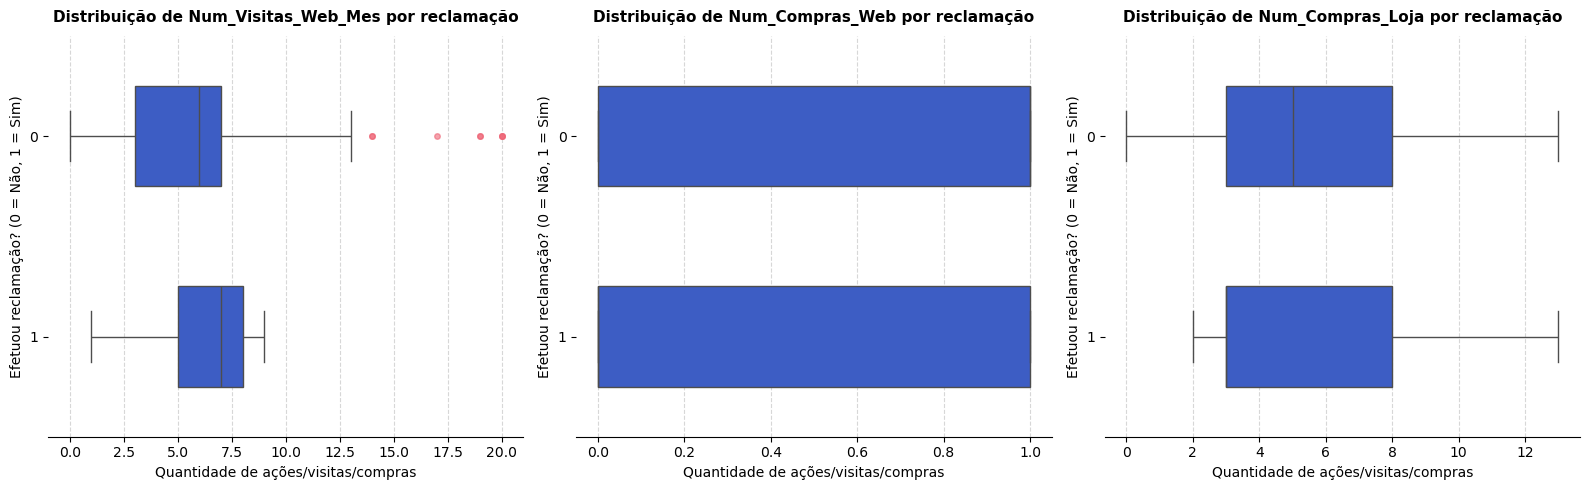

In [ ]:
# Lista das colunas numéricas de comportamento a serem plotadas
colunas = ['Num_Visitas_Web_Mes', 'Num_Compras_Web', 'Num_Compras_Loja']

# Configuração do tamanho do gráfico
plt.figure(figsize=(16, 5))

# Loop para criar os subplots distribuídos lado a lado
for i, coluna in enumerate(colunas, 1):
    plt.subplot(1, 3, i)
    
    # sns.boxplot horizontal: 'x' recebe os valores numéricos e 'y' agrupa por Reclamação
    sns.boxplot(
        data=base, 
        x=coluna, 
        y=base['Reclamacao'].astype(str),
        color="#2751DA",           
        width=0.5,
        flierprops={
            'marker': 'o', 
            'markersize': 4, 
            'markerfacecolor': '#EE6677',
            'markeredgecolor': '#EE6677',
            'alpha': 0.6
        }
    )
    
    # Customizações
    plt.title(f'Distribuição de {coluna} por reclamação', fontsize=11, weight='bold', pad=10)
    plt.xlabel('Quantidade de ações/visitas/compras')
    plt.ylabel('Efetuou reclamação? (0 = Não, 1 = Sim)')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    sns.despine(left=True)

# Ajuste de espaçamento e exibição do gráfico
plt.tight_layout()
plt.show()

In [ ]:
# Filtragem do DataFrame trazendo apenas as linhas onde houve reclamação (igual a 1)
# e seleção de apenas as 3 colunas de interesse para a visualização
consulta_reclamacoes = base[base['Reclamacao'] == 1][[
    'Num_Visitas_Web_Mes', 'Num_Compras_Web', 'Num_Compras_Loja'
]]

# Exibição do resultado
print(f"Total de registros encontrados com reclamação: {len(consulta_reclamacoes)}")
display(consulta_reclamacoes)

Total de registros encontrados com reclamação: 21


,Num_Visitas_Web_Mes,Num_Compras_Web,Num_Compras_Loja
78,3,0,3
147,8,0,2
192,5,0,2
271,5,0,4
355,7,0,3
358,2,1,5
590,7,0,2
972,8,0,4
1041,8,0,3
1069,2,0,13


**Insight:** \
O comportamento dos clientes nos canais de compra não sofre alterações drásticas devido a reclamações, reforçando padrões de consumo homogêneos. No painel de **Visitas Web**, os clientes que reclamaram (1) mostram engajamento digital mais focado, com mediana próxima a 7 acessos e sem os valores extremos observados no grupo satisfeito (0). No canal digital (**Compras Web**), o padrão se mantém achatado e idêntico para ambos os públicos entre 0 e 1 unidade, evidenciando uma forte limitação nessa métrica. Por fim, as **Compras em Loja** revelam um cenário muito semelhante entre os grupos, com a mesma faixa de distribuição de 3 a 8 compras físicas e mediana idêntica de 5 transações presenciais, provando que o descontentamento não afeta a frequência de compra nem direciona a preferência entre o canal físico e o online.

Aprofundando a análise, foi identificado que o total de registros com reclamação é de apenas 21 clientes. Essa baixa amostragem justifica o formato achatado e a ausência de caudas longas de distribuição nas caixas do grupo insatisfeito. Ao inspecionar esses 21 registros, a rigidez nas **Compras Web** é confirmada: a grande maioria efetuou zero compras online, com raríssimas exceções registrando apenas 1 compra. Em contrapartida, o canal físico demonstra sua força, com o histórico desses mesmos clientes registrando volumes consistentes de **Compras em Loja**, alcançando picos de até 12 e 13 compras presenciais. Isso consolida o diagnóstico de que a insatisfação pontual desse microgrupo não gerou uma ruptura ou boicote no canal preferencial de consumo.

### Integração de canais, visitas ao site, quantidade de compras realizadas do site e compras físicas

**Objetivo:** identificar o canal de compra predominante dos clientes.

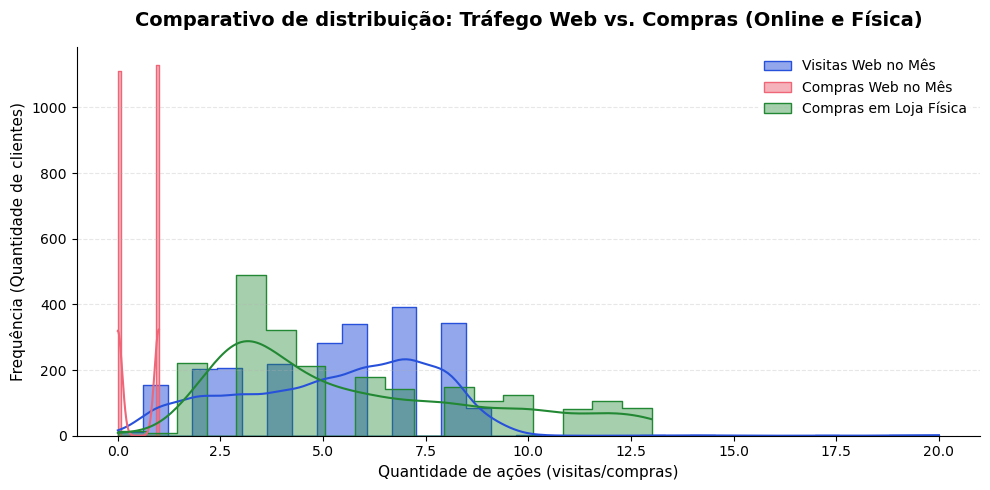

In [82]:
# Configuração do tamanho do gráfico
plt.figure(figsize=(10, 5))

# Histograma para Num_Visitas_Web_Mes (Azul)
sns.histplot(
    data=base,
    x='Num_Visitas_Web_Mes',
    color='#2751DA',           
    label='Visitas Web no Mês',
    element='step',             
    kde=True,                   
    alpha=0.5                   
)

# Histograma para Num_Compras_Web (Vermelho)
sns.histplot(
    data=base,
    x='Num_Compras_Web',
    color='#EE6677',          
    label='Compras Web no Mês',
    element='step',
    kde=True,
    alpha=0.5
)

# Histograma para Num_Compras_Loja (Verde)
sns.histplot(
    data=base,
    x='Num_Compras_Loja',
    color='#228833',          
    label='Compras em Loja Física',
    element='step',
    kde=True,
    alpha=0.4                  
)

# Customizações e rótulos atualizados
plt.title('Comparativo de distribuição: Tráfego Web vs. Compras (Online e Física)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Quantidade de ações (visitas/compras)', fontsize=11)
plt.ylabel('Frequência (Quantidade de clientes)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Legendas
plt.legend(frameon=True, facecolor='white', edgecolor='none')

# Limpar as bordas pretas desnecessárias
sns.despine()

# Ajuste de espaçamento e exibição do gráfico
plt.tight_layout()
plt.show()

**Insight:** \
O gráfico confirma visualmente o funil de conversão multicanal e valida a hipótese de que o número de compras via web não se relaciona diretamente com a quantidade de acessos. Enquanto a distribuição de **Visitas Web no Mês** apresenta um comportamento disperso, concentrando a maior parte dos clientes em uma faixa de 5 a 8 acessos mensais, a distribuição de **Compras Web no Mês** exibe um comportamento severamente limitado, travado de forma maciça em apenas duas barras sólidas entre 0 e 1 compra por cliente. A **Compras em Loja Física** esclarece o abismo estatístico ao revelar uma curva de distribuição muito mais robusta e saudável, distribuindo-se de forma contínua até 13 compras por cliente, com um pico expressivo de concentração entre 3 e 4 transações presenciais. A sobreposição direta entre a curva de visitas digitais (azul) e a de compras físicas (verde) evidencia que o site funciona predominantemente como um canal de pesquisa, navegação ou comparação de preços (webrooming), provando que o alto volume de tráfego digital dos usuários não é perdido, mas sim efetivamente canalizado e convertido em vendas nas lojas físicas.

### Compras realizadas com desconto diretamente do site e fisico

**Objetivo:** entender se clientes que utilizam mais ofertas/descontos apresentam preferência por algum canal.

**Gráfico:** Scatter Plot ou gráfico de barras por faixas de compras com desconto.\
X = NumDealsPurchases \
Y = Num_Compras_Web \
outro \
X = NumDealsPurchases \
Y = Num_Visitas_Web_Mes \
**Variáveis:** NumDealsPurchases (Localizar) ++ Num_Compras_Web + Num_Visitas_Web_Mes;

### Valores gastos em cada produto diretamente do site e fisico

**Objetivo:** identificar quais categorias de produtos concentram maior consumo e verificar o comportamento dos clientes em relação aos canais de compra.

**Gráfico:** Gráfico de barras \
**Variáveis:** Gasto_Vinhos + Gasto_Frutas + Gasto_Carnes + Gasto_Peixes + Gasto_Doces + Gasto_Ouro ++ Num_Compras_Web + Num_Compras_Loja.

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [ ]:
# seu código aqui

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [ ]:
# seu código aqui

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [ ]:
# seu código aqui